# Ideal two-spin QEC in a five-state NV center

> **Scope:** recovery is instantaneous and perfect, and is applied once to a copy of the state at readout. 

## Outline

1. Choose the physical parameters.
2. Build the five-state NV Lindblad model.
3. Construct and verify the two-spin code.
4. Encode one logical state and evolve it without interruption.
5. Apply ideal recovery at readout and decode.
6. Average over six input states and compare with the best bare qubit.
7. Repeat the benchmark for spins 3 and 7 with $A_\perp=0$.


## Main experimental parameters

- `SPIN_IDS` selects two built-in $^{13}\mathrm C$ spins. Their signed longitudinal and transverse hyperfine components are $A_{\parallel,j}$ and $A_{\perp,j}$ in kHz.
- `B_FIELD_T` is the axial magnetic field $B$ in tesla; it sets $\omega_L=2\pi\gamma_{^{13}\mathrm C}B$.
- `LASER_POWER_UW` is the optical power $P$ in $\mu\mathrm W$.
- `EXCITATION_RATE_PER_US_PER_UW` is the model calibration $c_{\rm exc}$, so the pump rate is $W_{\rm pump}=Pc_{\rm exc}$ in $\mu\mathrm s^{-1}$.
- `DURATION_US` and `SAMPLE_DT_US` set the plotted stopping times. `READOUT_TIME_US` selects one of those times for the step-by-step calculation.


In [15]:
SPIN_IDS = (3, 7)
B_FIELD_T = 0.05
LASER_POWER_UW = 5.0
EXCITATION_RATE_PER_US_PER_UW = 1.0

DURATION_US = 20.0
SAMPLE_DT_US = 0.5
READOUT_TIME_US = 10.0


### Imports

All dynamics and QEC operations below come from `nv_qec`; NumPy is used only for compact state preparation and reporting, and Matplotlib for the requested comparison plot.


In [16]:
from dataclasses import replace
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "nv_qec").is_dir():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))


In [17]:
import matplotlib.pyplot as plt
import numpy as np

from nv_qec import (
    BUILTIN_SPINS,
    OpticalParameters,
    SimulationConfig,
    simulate_qec_memory,
)
from nv_qec import model as nv_model
from nv_qec import qec

np.set_printoptions(precision=5, suppress=True)


## 1. Build the physical five-state model

The electron basis is

$$\{|g_0\rangle,|g_1\rangle,|e_0\rangle,|e_1\rangle,|s\rangle\},$$

comprising two ground branches, two optically excited branches, and one metastable singlet. Each electron state is tensored with two nuclear spin-$\tfrac12$ spaces, so $\dim\mathcal H=5\times2\times2=20$.

In angular-frequency units of $\mathrm{rad}/\mu\mathrm s$,

$$H_{\rm free}=\omega_L(I_{z,1}+I_{z,2}),$$

$$H_{g_1}=\sum_{j=1}^{2}\left[(\omega_L-A_{\parallel,j})I_{z,j}+A_{\perp,j}I_{x,j}\right].$$

The $g_0,e_0,e_1,$ and $s$ blocks use $H_{\rm free}$; only $g_1$ uses $H_{g_1}$. Inputs in kHz are converted once by $A\mapsto2\pi\,10^{-3}A$.

Optical pumping, radiative decay, intersystem crossing (ISC), and singlet decay enter through eight collapse operators in

$$\dot\rho=-i[H,\rho]+\sum_\mu\left(L_\mu\rho L_\mu^\dagger-\tfrac12\{L_\mu^\dagger L_\mu,\rho\}\right).$$


In [18]:
spin_a, spin_b = (BUILTIN_SPINS[spin_id] for spin_id in SPIN_IDS)
optical = OpticalParameters(
    laser_power_uw=LASER_POWER_UW,
    excitation_rate_per_us_per_uw=EXCITATION_RATE_PER_US_PER_UW,
)
config = SimulationConfig(
    duration_us=DURATION_US,
    sample_dt_us=SAMPLE_DT_US,
    b_field_t=B_FIELD_T,
    optical=optical,
)
model = nv_model.build_nv_model(
    spin_a, spin_b, b_field_t=B_FIELD_T, optical=optical
)


The two hyperfine tensors determine the conditional nuclear precession, while the seven displayed rates determine the stochastic optical transitions. The excitation rate appears once for each of $g_0\to e_0$ and $g_1\to e_1$.


In [19]:
print(f"Hilbert-space dimension: {model.dimension}")
for spin in (spin_a, spin_b):
    print(
        f"spin {spin.id}: A_parallel={spin.a_parallel_khz:g} kHz, "
        f"A_perp={spin.a_perp_khz:g} kHz"
    )
print("\nOptical rates (1/us):")
for transition, rate in optical.rates_per_us.items():
    print(f"  {transition:28s} {rate:9.5f}")


Hilbert-space dimension: 20
spin 3: A_parallel=-49.837 kHz, A_perp=101.007 kHz
spin 7: A_parallel=-33.962 kHz, A_perp=26 kHz

Optical rates (1/us):
  optical_pump                   5.00000
  radiative_e0                  66.15385
  radiative_e1                  64.28571
  intersystem_crossing_e0       10.76923
  intersystem_crossing_e1       78.57143
  singlet_to_g0                  4.72222
  singlet_to_g1                  0.83333


## 2. Construct the common-fluctuator code

The code-design couplings are $g_j=-A_{\parallel,j}$. The implementation first orders the spins so $|g_1|\ge |g_2|$ and chooses a common sign with $g_1>0$, then maps the code back to the requested spin order. Define

$$a=\sqrt{\frac{g_1-g_2}{2g_1}},\qquad b=\sqrt{\frac{g_1+g_2}{2g_1}},$$

$$|\chi_0\rangle=a|0\rangle+b|1\rangle,\qquad
|\chi_1\rangle=-b|0\rangle+a|1\rangle.$$

The logical and correctable-error bases are

$$|0_L\rangle=|\chi_0\rangle|0\rangle,\quad
|1_L\rangle=|\chi_1\rangle|1\rangle,$$

$$|0_E\rangle=|\chi_1\rangle|0\rangle,\quad
|1_E\rangle=|\chi_0\rangle|1\rangle.$$


In [20]:
code = qec.build_common_fluctuator_code(spin_a, spin_b)
g1, g2 = code.design_couplings_khz
a = np.sqrt((g1 - g2) / (2.0 * g1))
b = np.sqrt((g1 + g2) / (2.0 * g1))

print(f"internal spin order: {code.ordered_spin_ids}")
print(f"(g1, g2) = ({g1:.6g}, {g2:.6g}) kHz")
print(f"(a, b)   = ({a:.6f}, {b:.6f})")


internal spin order: (3, 7)
(g1, g2) = (49.837, 33.962) kHz
(a, b)   = (0.399085, 0.916914)


### Why the error is correctable

Let $W=(|0_L\rangle,|1_L\rangle)$ and

$$H_E=g_a Z_a+g_b Z_b.$$

The identities $W^\dagger H_EW=0$ and $W^\dagger H_E^2W\propto I$ mean the fluctuator does not distinguish logical states to first order. Recovery uses

$$K_0=P_L,\qquad K_1=(U_\chi\otimes I)P_E,$$

where $U_\chi$ exchanges $|\chi_0\rangle$ and $|\chi_1\rangle$. The final matrix below confirms $\sum_rK_r^\dagger K_r=I$.


In [21]:
H_error = qec.common_fluctuator_error_hamiltonian(spin_a, spin_b)
W = code.logical_isometry
completeness = sum(K.conj().T @ K for K in code.recovery_kraus)

checks = {
    "W^dagger W": W.conj().T @ W,
    "W^dagger H_E W [kHz]": W.conj().T @ H_error @ W,
    "sum K^dagger K": completeness,
}
for label, matrix in checks.items():
    print(f"{label}:\n{np.round(matrix, 10)}\n")


W^dagger W:
[[1.+0.j 0.+0.j]
 [0.+0.j 1.+0.j]]

W^dagger H_E W [kHz]:
[[-0.+0.j  0.+0.j]
 [ 0.+0.j  0.+0.j]]

sum K^dagger K:
[[ 1.+0.j  0.+0.j  0.+0.j  0.+0.j]
 [ 0.+0.j  1.+0.j  0.+0.j -0.+0.j]
 [ 0.+0.j  0.+0.j  1.+0.j  0.+0.j]
 [ 0.+0.j -0.+0.j  0.+0.j  1.+0.j]]



## 3. Encode a logical state

To make the protocol concrete, take $|+\rangle=(|0\rangle+|1\rangle)/\sqrt2$. The existing encoder applies the isometry $W$,

$$\rho_{\rm nuc}(0)=W|+\rangle\!\langle+|W^\dagger.$$

The electron begins in $|g_0\rangle$, giving $\rho(0)=|g_0\rangle\!\langle g_0|\otimes\rho_{\rm nuc}(0)$.


In [8]:
ket_plus = np.array([1.0, 1.0], dtype=complex) / np.sqrt(2.0)
rho_logical = qec.density_matrix(ket_plus)
rho_encoded = qec.encode_logical_density(rho_logical, code)

ket_g0 = np.zeros(model.electron_dimension, dtype=complex)
ket_g0[0] = 1.0
rho_initial = np.kron(qec.density_matrix(ket_g0), rho_encoded)

print(f"encoded nuclear shape: {rho_encoded.shape}")
print(f"Tr[rho(0)] = {np.trace(rho_initial).real:.12f}")


encoded nuclear shape: (4, 4)
Tr[rho(0)] = 1.000000000000


## 4. Evolve without intermediate recovery

The full $20$-dimensional density matrix now evolves in the laboratory frame under the five-state Lindblad generator $\mathcal L$. The inputs are the Hamiltonian fixed by $(B,A_\parallel,A_\perp)$, the optical rates fixed by `optical`, and the uninterrupted interval `READOUT_TIME_US`:

$$\rho(t)=e^{t\mathcal L}\rho(0).$$

No recovery acts during this interval; the state below is the state immediately before readout.


In [9]:
generator = nv_model.lindblad_generator(model)
rho_before_recovery = nv_model.propagate_states(
    generator, [rho_initial], READOUT_TIME_US, model.dimension
)[0]

print(f"Liouvillian shape: {generator.shape}")
print(f"Tr[rho({READOUT_TIME_US:g} us)] = {np.trace(rho_before_recovery).real:.12f}")


Liouvillian shape: (400, 400)
Tr[rho(10 us)] = 1.000000000000


## 5. Recover once, at readout

The code and recovery are defined in the nuclear rotating frame. With

$$R(t)=e^{-iH_{\rm free}t},$$

each rotating-frame Kraus operator is applied in the laboratory frame as $R(t)K_rR^\dagger(t)$. The absolute stopping time matters because $A_{\perp,j}\ne0$. Recovery is applied to a readout copy, so it never changes the trajectory used at later stopping times.


In [22]:
rho_after_recovery = qec.apply_recovery_in_lab_frame(
    rho_before_recovery, code, model, READOUT_TIME_US
)

print(f"Tr[recovered state] = {np.trace(rho_after_recovery).real:.12f}")


Tr[recovered state] = 1.000000000000


## 6. Trace out the electron and decode

Readout first forms the nuclear state $\rho_{\rm nuc}^{\rm lab}=\operatorname{Tr}_e\rho$, then returns it to the rotating frame,

$$\rho_{\rm nuc}^{\rm rot}(t)=R^\dagger(t)\rho_{\rm nuc}^{\rm lab}(t)R(t),$$

and finally decodes with $\rho_L^{\rm out}=W^\dagger\rho_{\rm nuc}^{\rm rot}W$. The decoder does not renormalize: any population outside the logical subspace counts as failure.


In [23]:
rho_nuclear_lab = nv_model.trace_out_electron(rho_after_recovery, model)
rho_nuclear_rot = nv_model.to_nuclear_rotating_frame(
    rho_nuclear_lab, model, READOUT_TIME_US
)
rho_decoded = qec.decode_logical_density(rho_nuclear_rot, code)
plus_fidelity = float(np.real(ket_plus.conj() @ rho_decoded @ ket_plus))

print("decoded logical density matrix:")
print(np.round(rho_decoded, 6))
print(f"\n<+|rho_out|+> = {plus_fidelity:.9f}")


decoded logical density matrix:
[[0.5    +0.j     0.49563+0.0027j]
 [0.49563-0.0027j 0.5    +0.j    ]]

<+|rho_out|+> = 0.995630753


## 7. Six-state memory fidelity and the bare-qubit benchmark

One input state is not enough to characterize a memory channel. The simulator repeats the complete protocol for the six Pauli eigenstates $\{\pm X,\pm Y,\pm Z\}$ and reports

$$F_6=\frac16\sum_{\psi}\langle\psi|\rho_{\rm out}^{(\psi)}|\psi\rangle.$$

It also finds the exact continuous final virtual-$Z$ phase that maximizes $F_6$. For a fair bare benchmark, the same six states are stored in each physical spin while the other spin is maximally mixed. Both controls use the same electron state, elapsed optical noise, rotating frame, and virtual-$Z$ rule, but no QEC recovery:

$$F_{\rm bare}^{\rm best}(t)=\max\{F_a(t),F_b(t)\}.$$


In [ ]:
result = simulate_qec_memory(config, spin_a, spin_b)

print(f"final logical fidelity:   {re   sult.qec_phase_corrected[-1]:.9f}")
print(f"final best bare fidelity: {result.best_single[-1]:.9f}")
print(f"final QEC advantage:      {result.qec_advantage[-1]:+.9f}")


final logical fidelity:   0.990790147
final best bare fidelity: 0.995265817
final QEC advantage:      -0.004475670


### Logical fidelity versus the best bare fidelity

The plotted quantities are the phase-corrected six-state averages. Their vertical difference is

$$\Delta F(t)=F_L(t)-F_{\rm bare}^{\rm best}(t).$$

A positive $\Delta F$ is an ideal-model crossing only; it does not include the experimental cost of encoding, recovery, or readout.


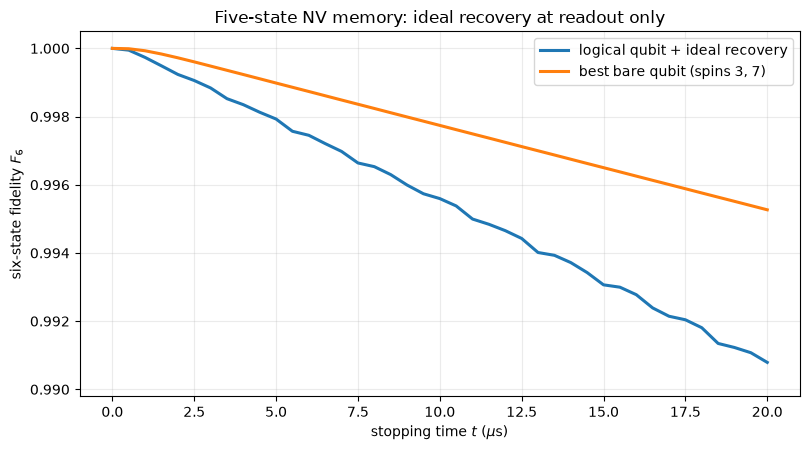

In [13]:
fig, ax = plt.subplots(figsize=(8.2, 4.6))
ax.plot(
    result.t_us,
    result.qec_phase_corrected,
    lw=2.2,
    label="logical qubit + ideal recovery",
)
ax.plot(
    result.t_us,
    result.best_single,
    lw=2.2,
    label=f"best bare qubit (spins {spin_a.id}, {spin_b.id})",
)

floor = min(result.qec_phase_corrected.min(), result.best_single.min())
margin = max(1e-3, 0.08 * (1.0 - floor))
ax.set_ylim(max(0.0, floor - margin), 1.0005)
ax.set(
    xlabel=r"stopping time $t$ ($\mu$s)",
    ylabel=r"six-state fidelity $F_6$",
)
ax.set_title("Five-state NV memory: ideal recovery at readout only")
ax.grid(alpha=0.25)
ax.legend()
fig.tight_layout()
plt.show()


## 8. Longitudinal-only case: spins 3 and 7 with $A_\perp=0$

We now retain the measured longitudinal couplings $A_{\parallel,3}$ and $A_{\parallel,7}$ but set both transverse components to zero:

$$A_{\perp,3}=A_{\perp,7}=0.$$

The conditional nuclear Hamiltonian becomes

$$H_{g_1}^{(\parallel)}=\sum_{j\in\{3,7\}}(\omega_L-A_{\parallel,j})I_{z,j},$$

so, relative to $H_{\rm free}$, the electron produces only the longitudinal fluctuation $-\sum_j A_{\parallel,j}I_{z,j}$. This is proportional to the common-fluctuator error used to construct the code. All optical rates, the magnetic field, stopping times, and the readout-only recovery protocol remain unchanged.

In [14]:
spin_3_zero_perp = replace(BUILTIN_SPINS[3], a_perp_khz=0.0)
spin_7_zero_perp = replace(BUILTIN_SPINS[7], a_perp_khz=0.0)

zero_perp_result = simulate_qec_memory(
    config, spin_3_zero_perp, spin_7_zero_perp
)

print("transverse couplings:", (
    spin_3_zero_perp.a_perp_khz,
    spin_7_zero_perp.a_perp_khz,
), "kHz")
print(f"final logical fidelity:   {zero_perp_result.qec_phase_corrected[-1]:.9f}")
print(f"final best bare fidelity: {zero_perp_result.best_single[-1]:.9f}")
print(f"final QEC advantage:      {zero_perp_result.qec_advantage[-1]:+.9f}")


transverse couplings: (0.0, 0.0) kHz
final logical fidelity:   0.999565367
final best bare fidelity: 0.996109753
final QEC advantage:      +0.003455615


### Fidelity with purely longitudinal hyperfine coupling

The comparison uses the same phase-corrected six-state fidelity $F_6$. The shaded region is where the logical memory exceeds the better of the two bare nuclear memories.

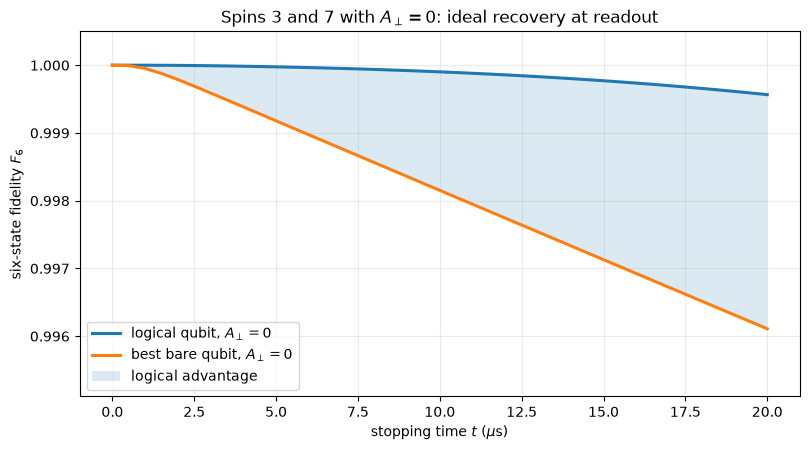

In [15]:
fig, ax = plt.subplots(figsize=(8.2, 4.6))
t = zero_perp_result.t_us
logical = zero_perp_result.qec_phase_corrected
bare = zero_perp_result.best_single

ax.plot(t, logical, lw=2.2, label=r"logical qubit, $A_\perp=0$")
ax.plot(t, bare, lw=2.2, label=r"best bare qubit, $A_\perp=0$")
ax.fill_between(
    t, bare, logical, where=logical >= bare,
    alpha=0.16, label="logical advantage",
)

floor = min(logical.min(), bare.min())
margin = max(1e-3, 0.08 * (1.0 - floor))
ax.set_ylim(max(0.0, floor - margin), 1.0005)
ax.set(
    xlabel=r"stopping time $t$ ($\mu$s)",
    ylabel=r"six-state fidelity $F_6$",
)
ax.set_title(r"Spins 3 and 7 with $A_\perp=0$: ideal recovery at readout")
ax.grid(alpha=0.25)
ax.legend()
fig.tight_layout()
plt.show()


Removing $A_\perp$ aligns the simulated noise more closely with the longitudinal common-fluctuator model. The difference from the full-coupling result above therefore shows how transverse hyperfine dynamics limit this ideal two-spin code.

## Protocol in one line

$$
\rho_L
\xrightarrow{\;W\;}
|g_0\rangle\!\langle g_0|\otimes W\rho_LW^\dagger
\xrightarrow{\;e^{t\mathcal L}\;}
\rho(t)
\xrightarrow{\;\{R(t)K_rR^\dagger(t)\}\;}
\rho_{\rm rec}(t)
\xrightarrow{\;\operatorname{Tr}_e,\,R^\dagger,\,W^\dagger\;}
\rho_L^{\rm out}(t)
\xrightarrow{\;\{\pm X,\pm Y,\pm Z\}\;}
F_6(t).
$$
